# ===================================
# -- GCP FinOps Project - 
# ===================================

## ------------------------------------
 Name: GCP_FinOps
 
 Author: Jorge Rodriguez

 Created: Jan-24-2025

 Last Compiled: may-24-2026

 Description: 
 
 This program access Big Querry at GCP to access the Billing Table to get all the records for the time perido selectd
## ------------------------------------

## Python Kernel 3.13.7

In [1]:
#! pip3 install colorama
#! pip3 install --upgrade google-cloud-bigquery
#! pip3 install db-dtypes
#----------- Google CLI <BEGIN> ----------------------
# gcloud auth application-default login
# Credentials saved to file: [/Users/jorge.rodriguez/.config/gcloud/application_default_credentials.json]
# ---------- Google CLI <END> ------------------------
#

In [2]:
# Copyright 2022 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# from googleapiclient import discovery
from google.cloud import bigquery


# Use the BigQuery Storage API v1 client. In many environments the module is available
# as google.cloud.bigquery_storage_v1. Falling back if necessary keeps compatibility.
try:
	from google.cloud import bigquery_storage_v1 as bigquery_storage
except Exception:
	try:
		from google.cloud import bigquery_storage
	except Exception:
		# If the import fails at runtime, set to None and handle accordingly later.
		bigquery_storage = None

#from google.cloud import billing
from google.api_core import client_info as http_client_info
from google.api_core.exceptions import PermissionDenied
from google.cloud.exceptions import NotFound
import argparse
import sys
#from colorama import Back
#from colorama import Style
import db_dtypes
import pandas as pd
from google.oauth2 import service_account
from google.cloud.bigquery.schema import SchemaField

# Other packages
import pandas as pd
import json 
import ast
import datetime
import time
from datetime import date
from dateutil.relativedelta import relativedelta
import seaborn as sns
import subprocess
from time import time, sleep
import webbrowser
import matplotlib.pyplot as plt


# Connection to Big Query for the billing Project using the CLI Credentials, saved it locally

In [3]:
client = bigquery.Client(project='billing-query-371121')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
Python(89342) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


# Getting the Datasetes available at the project:

In [4]:
datasets = list(client.list_datasets())  # Make an API request.
project = client.project

if datasets:
    print("Datasets in project {}:".format(project))
    for dataset in datasets:
        print("\t{}".format(dataset.dataset_id))
else:
    print("{} project does not contain any datasets.".format(project))

Datasets in project billing-query-371121:
	all_billing_data


In [5]:
dataset_id = client.project + '.' + dataset.dataset_id
dataset_id

'billing-query-371121.all_billing_data'

# Get the Table we need from the Dataset

In [6]:
# TODO(developer): Set dataset_id to the ID of the dataset that contains
#                  the tables you are listing.
# dataset_id = 'your-project.your_dataset'


tables = client.list_tables(dataset_id)  # Make an API request.

print("Tables contained in '{}':".format(dataset_id))
for table in tables:
    print("{}.{}.{}".format(table.project, table.dataset_id, table.table_id))
    table_id= table.project + '.' + table.dataset_id + '.'+ table.table_id

table_id
table = table.dataset_id + '.'+ table.table_id
table


Tables contained in 'billing-query-371121.all_billing_data':
billing-query-371121.all_billing_data.gcp_billing_export_resource_v1_01C5AB_0209B1_81C892
billing-query-371121.all_billing_data.gcp_billing_export_v1_01C5AB_0209B1_81C892


'all_billing_data.gcp_billing_export_v1_01C5AB_0209B1_81C892'

# Select The Dates for the Report

In [7]:
reportStart = '2026-05-01'
reportEnd = '2026-06-01'
reportYear = '2026'
reportMonth = '05'

# Create the SQL for the date

In [8]:
# Build a narrower, parameterized query to reduce transfer size and improve speed
sql = f"""
SELECT
  cost,
  service,
  sku,
  project,
  usage,
  invoice,
  location,
  labels
FROM `{table_id}`
WHERE invoice.month = @invoice_month
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ScalarQueryParameter(
            "invoice_month", "STRING", f"{reportYear}{reportMonth}"
        )
    ]
)

sql

'\nSELECT\n  cost,\n  service,\n  sku,\n  project,\n  usage,\n  invoice,\n  location,\n  labels\nFROM `billing-query-371121.all_billing_data.gcp_billing_export_v1_01C5AB_0209B1_81C892`\nWHERE invoice.month = @invoice_month\n'

In [9]:
# Run query with parameters
job_config = bigquery.QueryJobConfig(
	query_parameters=[
		bigquery.ScalarQueryParameter(
			"invoice_month", "STRING", f"{reportYear}{reportMonth}"
		)
	]
)
x = client.query(sql, job_config=job_config)

In [9]:
# Run once if needed for faster dataframe downloads
#%pip install -q google-cloud-bigquery-storage pyarrow

In [50]:
#bqstorageclient = bigquery_storage.BigQueryReadClient()

#df = x.to_dataframe(bqstorage_client=bqstorageclient)

In [10]:
# Faster download path: use BigQuery Storage API when available
try:
    df = x.to_dataframe(create_bqstorage_client=True)
except Exception as e:
    print(f"BigQuery Storage API not available, falling back to standard download: {e}")
    df = x.to_dataframe()

print(f"Rows downloaded: {len(df):,}")

Rows downloaded: 5,516,868


# Print the Total Cost GCP

In [11]:
df['cost'].sum()

np.float64(511400.17636399955)

# Display the Schema 

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5516868 entries, 0 to 5516867
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   cost      float64
 1   service   object 
 2   sku       object 
 3   project   object 
 4   usage     object 
 5   invoice   object 
 6   location  object 
 7   labels    object 
dtypes: float64(1), object(7)
memory usage: 336.7+ MB


# Split the Json format to indepedent columns in the dataframe for better consumption and visulization

In [13]:
# Flatten the `service` column once and assign back safely
service_fields = (
    pd.json_normalize(df['service'])
    .reindex(columns=['id', 'description'])
    .rename(
        columns={
            'id': 'service_id',
            'description': 'service_description',
        }
    )
)

df[service_fields.columns] = service_fields

In [14]:
# Flatten the `sku` column once and assign back safely
sku_fields = (
    pd.json_normalize(df['sku'])
    .reindex(columns=['id', 'description'])
    .rename(
        columns={
            'id': 'sku_id',
            'description': 'sku_description',
        }
    )
)

df[sku_fields.columns] = sku_fields

In [15]:
# Flatten the `project` column once and assign back safely
project_fields = (
    pd.json_normalize(df['project'])
    .reindex(columns=['id', 'number', 'name', 'labels', 'ancestry_numbers', 'ancestors'])
    .rename(
        columns={
            'id': 'project_id',
            'number': 'project_number',
            'name': 'project_name',
            'labels': 'project_labels',
            'ancestry_numbers': 'project_ancestry_numbers',
            'ancestors': 'project_ancestors',
        }
    )
)

for col in ['project_labels', 'project_ancestors']:
    project_fields[col] = project_fields[col].map(
        lambda value: str(value) if value is not None else None
    )

df[project_fields.columns] = project_fields

In [16]:
# Flatten the `usage` column once and assign back safely
usage_fields = (
    pd.json_normalize(df['usage'])
    .reindex(columns=['amount', 'unit', 'amount_in_pricing_units', 'pricing_unit'])
    .rename(
        columns={
            'amount': 'usage_amount',
            'unit': 'usage_unit',
            'amount_in_pricing_units': 'usage_amount_in_pricing_units',
            'pricing_unit': 'usage_pricing_unit',
        }
    )
)

df[usage_fields.columns] = usage_fields

In [17]:
# Flatten the `invoice` column once, then derive year/month with vectorized string ops
invoice_fields = pd.json_normalize(df['invoice']).reindex(columns=['month', 'publisher_type'])
invoice_month_values = invoice_fields['month'].astype('string')

df['invoice_month'] = invoice_month_values.str[4:]
df['invoice_year'] = invoice_month_values.str[:4]
df['invoice_publisher_type'] = invoice_fields['publisher_type']

In [18]:
df['location']

0          {'location': 'us', 'country': 'US', 'region': ...
1          {'location': 'us', 'country': 'US', 'region': ...
2          {'location': 'us', 'country': 'US', 'region': ...
3          {'location': 'us', 'country': 'US', 'region': ...
4          {'location': 'us-east4', 'country': 'US', 'reg...
                                 ...                        
5516863    {'location': 'us', 'country': 'US', 'region': ...
5516864    {'location': 'us-central1', 'country': 'US', '...
5516865    {'location': 'us-east1', 'country': 'US', 'reg...
5516866    {'location': 'us-east1', 'country': 'US', 'reg...
5516867    {'location': 'us-east1', 'country': 'US', 'reg...
Name: location, Length: 5516868, dtype: object

In [19]:
'''
df['location_location'] = None
df['location_country'] = None
df['location_region'] = None
df['location_zone'] = None
'''


"\ndf['location_location'] = None\ndf['location_country'] = None\ndf['location_region'] = None\ndf['location_zone'] = None\n"

In [20]:
# Flatten the `location` column once and assign back safely
location_fields = (
    pd.json_normalize(df['location'])
    .reindex(columns=['location', 'country', 'region', 'zone'])
    .rename(
        columns={
            'location': 'location_location',
            'country': 'location_country',
            'region': 'location_region',
            'zone': 'location_zone',
        }
    )
)

df[location_fields.columns] = location_fields

# Get record 0 as sample to validate all the fields are OK

In [21]:
df.iloc[200,:]

cost                                                                           0.0
service                          {'id': '5490-F7B7-8DF6', 'description': 'Cloud...
sku                              {'id': '143F-A1B0-E0BE', 'description': 'Log S...
project                          {'id': 'prj-streaming-nonprod-09ed', 'number':...
usage                            {'amount': 14680.0, 'unit': 'bytes', 'amount_i...
invoice                            {'month': '202605', 'publisher_type': 'GOOGLE'}
location                         {'location': 'us', 'country': 'US', 'region': ...
labels                           [{'key': 'goog-resource-type', 'value': 'servi...
service_id                                                          5490-F7B7-8DF6
service_description                                                  Cloud Logging
sku_id                                                              143F-A1B0-E0BE
sku_description                                                   Log Storage cost
proj

In [22]:
df.iloc[200,:]['labels'][0]

{'key': 'goog-resource-type', 'value': 'service_account'}

In [23]:
#l = df[df['labels'] != "[]"]

In [24]:
#l

In [25]:
df['invoice_year'].unique()

<StringArray>
['2026']
Length: 1, dtype: string

In [26]:
df['invoice_month'].unique()

<StringArray>
['05']
Length: 1, dtype: string

In [27]:
df['cost'].sum()

np.float64(511400.17636399955)

# Get the name of the file to be saved it wiht the correct month and year

In [28]:
month = "GCP_Monthly_Cost_For_"+reportMonth+"_" + reportYear
month

'GCP_Monthly_Cost_For_05_2026'

# Save the Data as CSV

In [29]:
df.to_csv(month+".csv")

# Filter the Data for cost greather than $0.001

In [30]:
df1 = df[df['cost'] > 0.001]

In [31]:
df1['cost'].sum()

np.float64(511368.47126599995)

In [32]:
total_per_account_df = df1.groupby(['invoice_year','invoice_month','project_id','project_name']).agg({'cost':'sum'}).sort_values(by=['invoice_year','invoice_month','cost'], ascending=False).reset_index()
total_per_account_df['Total in Thousands'] = total_per_account_df['cost']/1000
total_per_account_df

,invoice_year,invoice_month,project_id,project_name,cost,Total in Thousands
0,2026,05,prj-dac-aces-ops-e42b,prj-dac-aces-ops,80434.120434,80.434120
1,2026,05,wo-wos-reporting-prod,wo-wos-reporting-prod,70260.174490,70.260174
2,2026,05,prj-edp-prod-edw-90be,prj-edp-prod-edw,36250.070460,36.250070
3,2026,05,prj-ai-traffic-dev-3623,prj-ai-traffic-dev,15243.016807,15.243017
4,2026,05,prj-initiatives-nonprod-1703,prj-initiatives-nonprod,13061.903553,13.061904
...,...,...,...,...,...,...
57,2026,05,prj-podops-nonprod-3ae1,prj-podops-nonprod,1.001723,0.001002
58,2026,05,prj-org-seed-435208,prj-common-mgt-admin,0.950057,0.000950
59,2026,05,prj-workstations-nonprod-5f3a,prj-workstations-nonprod,0.813305,0.000813
60,2026,05,prj-analytics-prod-f1ee,prj-analytics-prod,0.558671,0.000559


In [33]:
total_per_account_df['cost'].sum()

np.float64(303280.063841)

In [34]:
df1['cost'].sum()

np.float64(511368.47126599995)

/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_6303/4184626078.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


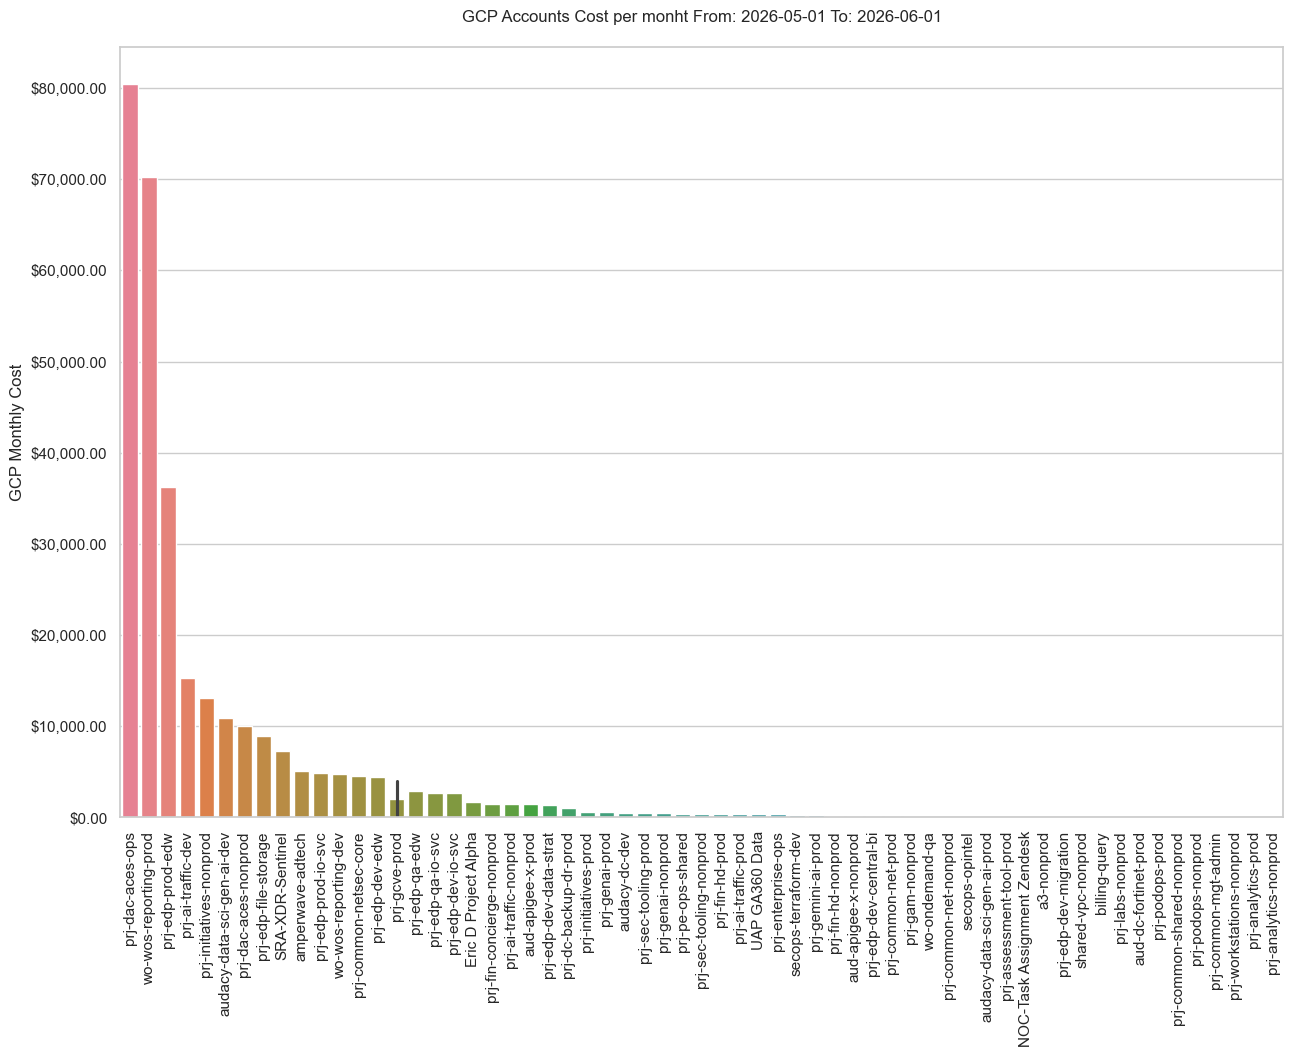

In [35]:
sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
fig, ax = plt.subplots(figsize=(15, 10))

monthly_cost = 1
#sns.set_color_codes("pastel")
sns.barplot(y="cost", x="project_name", data=total_per_account_df,
             hue='project_name', legend=False)


# Add a legend and informative axis label
#ax.legend(ncol=2, loc="lower right", frameon=True)
#ylim=(0, 35000),
ax.set( xlabel="",
       ylabel="GCP Monthly Cost")
ax.set_title("GCP Accounts Cost per monht From: " + reportStart + " To: " + reportEnd + '\n')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.2f}".format(int(x))))
#sns.despine(left=True, bottom=True)

In [36]:
total_per_service_df = df1[df1['invoice_year'].astype(int) > 2020].groupby(['invoice_year','service_description']).agg(Total=('cost','sum'))

In [37]:
t = total_per_service_df['Total'].sum()
t

np.float64(511368.47126600007)

In [38]:
services_df = total_per_service_df[(total_per_service_df['Total'] > 100)].sort_values(by='Total', ascending=False)

/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_6303/3561150770.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


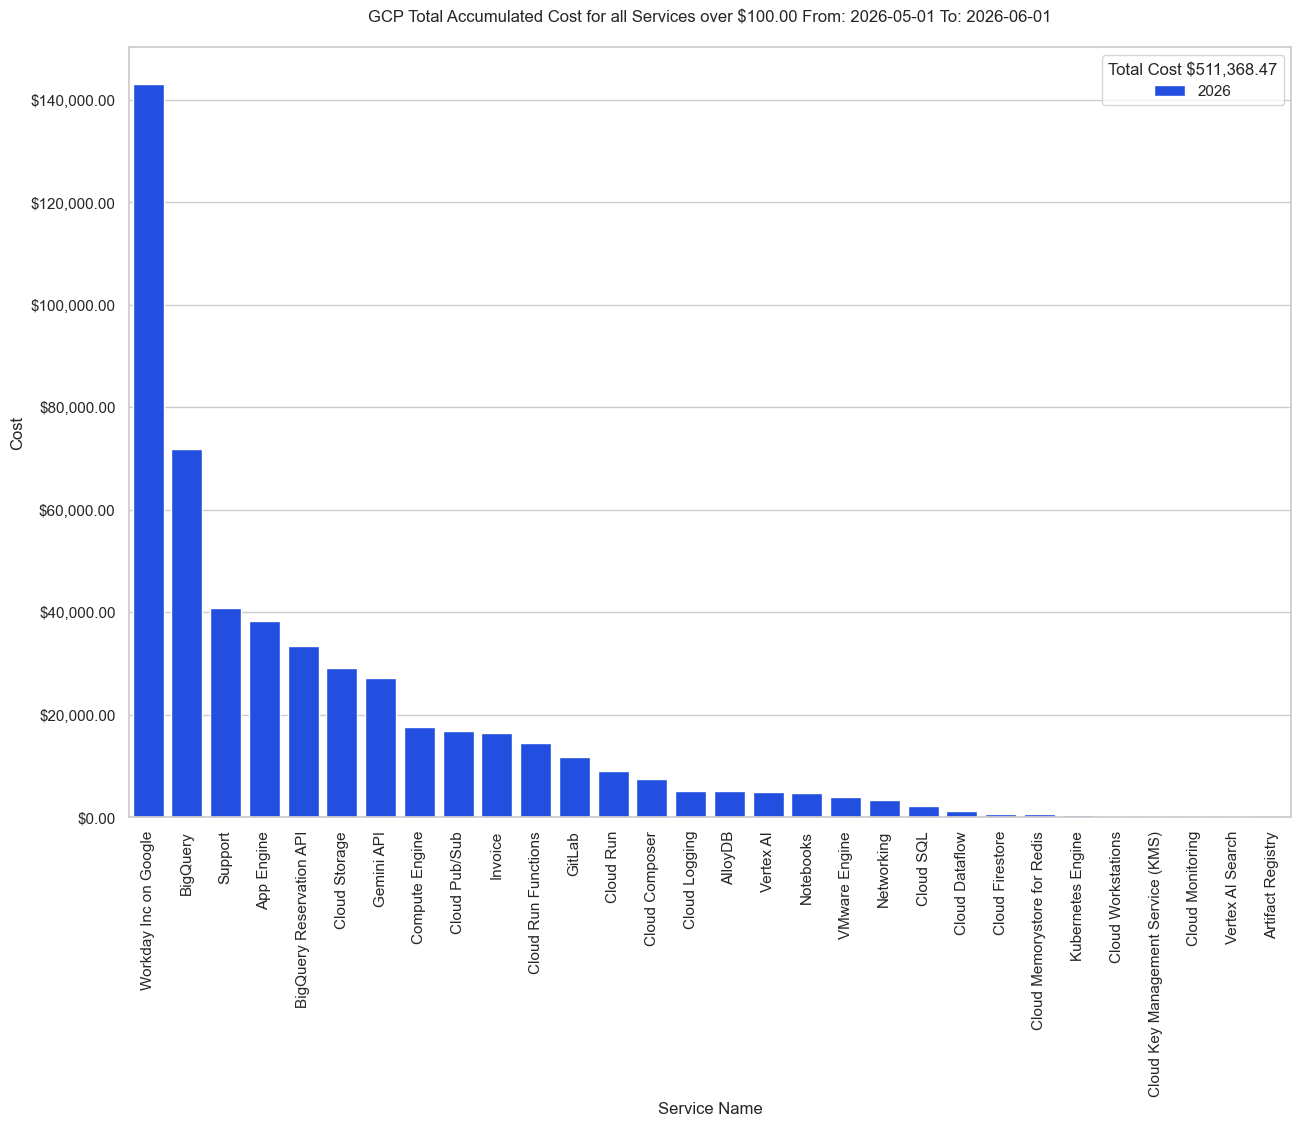

In [39]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(x="service_description", y="Total", data=services_df,
            hue='invoice_year', legend=True, color='green',palette='bright')


# Add a legend and informative axis label
#ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set_xlabel("Service Name")
ax.set_ylabel("Cost")
ax.legend(title="Total Cost $"+str("{:,.2f}".format(t)))
#ax.set_title("GCP Accounts Cost per monht From: " + reportStart + " To: " + reportEnd + '\n')
ax.set_title("GCP Total Accumulated Cost for all Services over $100.00 From: " + reportStart + " To: " + reportEnd + "\n")
#ax.set_title("AWS Total Cost for Jun, 2024 by Services over $100,000 \n")
#plt.xticks(rotation=90) 
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
#ax.set_xticklabels(labels=services_df['Service'],rotation=45)
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.2f}".format(int(x))))
plt.savefig("GCP Yearly Cost by Service ID")

# Reading all CSV Files:

In [3]:
import glob

# Get a list of all CSV files in the directory
csv_files = glob.glob('GCP_Monthly_Cost_For_*.csv')

# Create an empty list to store the DataFrames
dfs = [] 

# Loop over each CSV file and read it into a DataFrame
for file in csv_files:
    print("reading File: " + file)
    df = pd.read_csv(file) 
    dfs.append(df) 

# Concatenate all the DataFrames into one
combined_df = pd.concat(dfs, axis=0, ignore_index=True) 
'''
month_name = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
month_number = [1,2,3,4,5,6,7,8,9,10,11,12]
kafka_new ='Apache Kafka® & Apache Flink® on Confluent Cloud™ - Annual Commits'
kafka_old ='Apache Kafka® on Confluent Cloud™ - Annual Commits'
combined_df['Month No'] = combined_df['Month'].replace(month_name,month_number)
combined_df['Service'] = combined_df['Service'].replace('Datadog Pro','Datadog')
combined_df['Service'] = combined_df['Service'].replace(kafka_old,kafka_new)
'''

# Print the combined DataFrame
combined_df.sample(30)

reading File: GCP_Monthly_Cost_For_10_2024 2.csv


/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_40675/2974810727.py:12: DtypeWarning: Columns (43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


reading File: GCP_Monthly_Cost_For_07_2025.csv
reading File: GCP_Monthly_Cost_For_06_2025.csv


/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_40675/2974810727.py:12: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


reading File: GCP_Monthly_Cost_For_11_2023.csv


...

reading File: GCP_Monthly_Cost_For_02_2024 2.csv


/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_40675/2974810727.py:12: DtypeWarning: Columns (43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


reading File: GCP_Monthly_Cost_For_05_2023 2.csv


/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_40675/2974810727.py:12: DtypeWarning: Columns (43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


,Unnamed: 0,billing_account_id,service,sku,usage_start_time,usage_end_time,project,labels,system_labels,location,...,invoice_year,invoice_publisher_type,location_location,location_country,location_region,location_zone,price,cost_at_effective_price_default,cost_at_list_consumption_model,consumption_model
1114471,40803,01C5AB-0209B1-81C892,"{'id': '24E6-581D-38E5', 'description': 'BigQu...","{'id': '993F-6B6B-DCC4', 'description': 'Long ...",2025-07-08 10:00:00+00:00,2025-07-08 11:00:00+00:00,"{'id': 'prj-initiatives-nonprod-1703', 'number...","[{'key': 'cost-center', 'value': '9413-8330'}\...",[],"{'location': 'us', 'country': 'US', 'region': ...",...,2025,GOOGLE,us,US,NaN,NaN,"{'effective_price': Decimal('0.009250000'), 't...",0.000000,0.000000,"{'id': '7754-699E-0EBF', 'description': 'Defau..."
57954377,2007788,01C5AB-0209B1-81C892,"{'id': '5490-F7B7-8DF6', 'description': 'Cloud...","{'id': '143F-A1B0-E0BE', 'description': 'Log S...",2025-04-27 02:00:00+00:00,2025-04-27 03:00:00+00:00,"{'id': 'audacy-dc-dev', 'number': '77204542691...","[{'key': 'goog-resource-type', 'value': 'gcs_b...",[],"{'location': 'us', 'country': 'US', 'region': ...",...,2025,GOOGLE,us,US,NaN,NaN,NaN,NaN,NaN,NaN
86189910,792787,01C5AB-0209B1-81C892,"{'id': '24E6-581D-38E5', 'description': 'BigQu...","{'id': '947D-3B46-7781', 'description': 'Activ...",2024-02-15 15:00:00+00:00,2024-02-15 16:00:00+00:00,"{'id': 'wo-wos-reporting-291617', 'number': '1...",[],[],"{'location': 'us', 'country': 'US', 'region': ...",...,2024,NaN,us,US,NaN,NaN,NaN,NaN,NaN,NaN
27971333,157797,01C5AB-0209B1-81C892,"{'id': '5490-F7B7-8DF6', 'description': 'Cloud...","{'id': '143F-A1B0-E0BE', 'description': 'Log S...",2024-06-24 20:00:00+00:00,2024-06-24 21:00:00+00:00,"{'id': 'billing-query-371121', 'number': '1336...","[{'key': 'goog-resource-type', 'value': 'bigqu...",[],"{'location': 'us', 'country': 'US', 'region': ...",...,2024,NaN,us,US,NaN,NaN,NaN,NaN,NaN,NaN
31339779,383648,01C5AB-0209B1-81C892,"{'id': 'A1E8-BE35-7EBC', 'description': 'Cloud...","{'id': '3EAB-48F3-A0D5', 'description': 'Subsc...",2023-01-14 15:00:00+00:00,2023-01-14 16:00:00+00:00,"{'id': 'sra-xdr-sentinel-330418', 'number': '8...",[],[],"{'location': 'global', 'country': None, 'regio...",...,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72840214,1167371,01C5AB-0209B1-81C892,"{'id': '5490-F7B7-8DF6', 'description': 'Cloud...","{'id': '143F-A1B0-E0BE', 'description': 'Log S...",2025-09-04 14:00:00+00:00,2025-09-04 15:00:00+00:00,"{'id': 'prj-sandbox-nonprod-5fbf', 'number': '...","[{'key': 'goog-resource-type', 'value': 'cloud...",[],"{'location': 'us', 'country': 'US', 'region': ...",...,2025,GOOGLE,us,US,NaN,NaN,"{'effective_price': Decimal('0E-9'), 'tier_sta...",0.000000,0.000000,"{'id': '7754-699E-0EBF', 'description': 'Defau..."
81546273,1570102,01C5AB-0209B1-81C892,"{'id': 'A1E8-BE35-7EBC', 'description': 'Cloud...","{'id': '027D-B6C7-CCA2', 'description': 'Messa...",2025-03-11 17:00:00+00:00,2025-03-11 18:00:00+00:00,"{'id': 'wo-wos-reporting-prod', 'number': '399...",[],[],"{'location': 'us-east1', 'country': 'US', 'reg...",...,2025,GOOGLE,us-east1,US,us-east1,NaN,NaN,NaN,NaN,NaN
1083307,9639,01C5AB-0209B1-81C892,"{'id': '5490-F7B7-8DF6', 'description': 'Cloud...","{'id': '143F-A1B0-E0BE', 'description': 'Log S...",2025-07-25 12:00:00+00:00,2025-07-25 13:00:00+00:00,"{'id': 'prj-assessment-tool-prod-c0d4', 'numbe...","[{'key': 'goog-resource-type', 'value': 'gke_c...",[],"{'location': 'us', 'country': 'US', 'region': ...",...,2025,GOOGLE,us,US,NaN,NaN,"{'effective_price': Decimal('0E-9'), 'tier_sta...",0.000000,0.000000,"{'id': '7754-699E-0EBF', 'description': 'Defau..."
58478822,2532233,01C5AB-0209B1-81C892,"{'id': '5490-F7B7-8DF6', 'description': 'Cloud...","{'id': '143F-A1B0-E0BE', 'description': 'Log S...",2025-04-06 02:00:00+00:00,2025-04-06 03:00:00+00:00,"{'id': 'aud-apigee-x-prod', 'number': '1036566...","[{'key': 'goog-resource-type', 'value': 'gce_p...",[],"{'location': 'us', 'country': 'US', 

In [4]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87187035 entries, 0 to 87187034
Data columns (total 48 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Unnamed: 0                       int64  
 1   billing_account_id               object 
 2   service                          object 
 3   sku                              object 
 4   usage_start_time                 object 
 5   usage_end_time                   object 
 6   project                          object 
 7   labels                           object 
 8   system_labels                    object 
 9   location                         object 
 10  tags                             object 
 11  export_time                      object 
 12  cost                             float64
 13  currency                         object 
 14  currency_conversion_rate         float64
 15  usage                            object 
 16  credits                          object 
 17  invoic

In [5]:
#otal_per_month_df = combined_df.groupby(['Year','Month','Month No']).agg({'Cost':'sum'}).sort_values(by='Month')
total_per_month_df = combined_df.groupby(['invoice_year','invoice_month']).agg(Total_cost_per_Month=('cost','sum')).sort_values(by='invoice_month')
total_per_month_df['Cost_in_Millions'] = total_per_month_df['Total_cost_per_Month']/1000
total_per_month_df 

,,Total_cost_per_Month,Cost_in_Millions
invoice_year,invoice_month,,
2023,1,60981.840065,60.981840
2024,1,62115.759316,62.115759
2025,1,90466.182902,90.466183
2026,1,290679.532335,290.679532
2025,2,91866.694847,91.866695
2023,2,56849.031151,56.849031
2026,2,366778.793396,366.778793
2024,2,72661.033397,72.661033
2025,3,102711.107448,102.711107


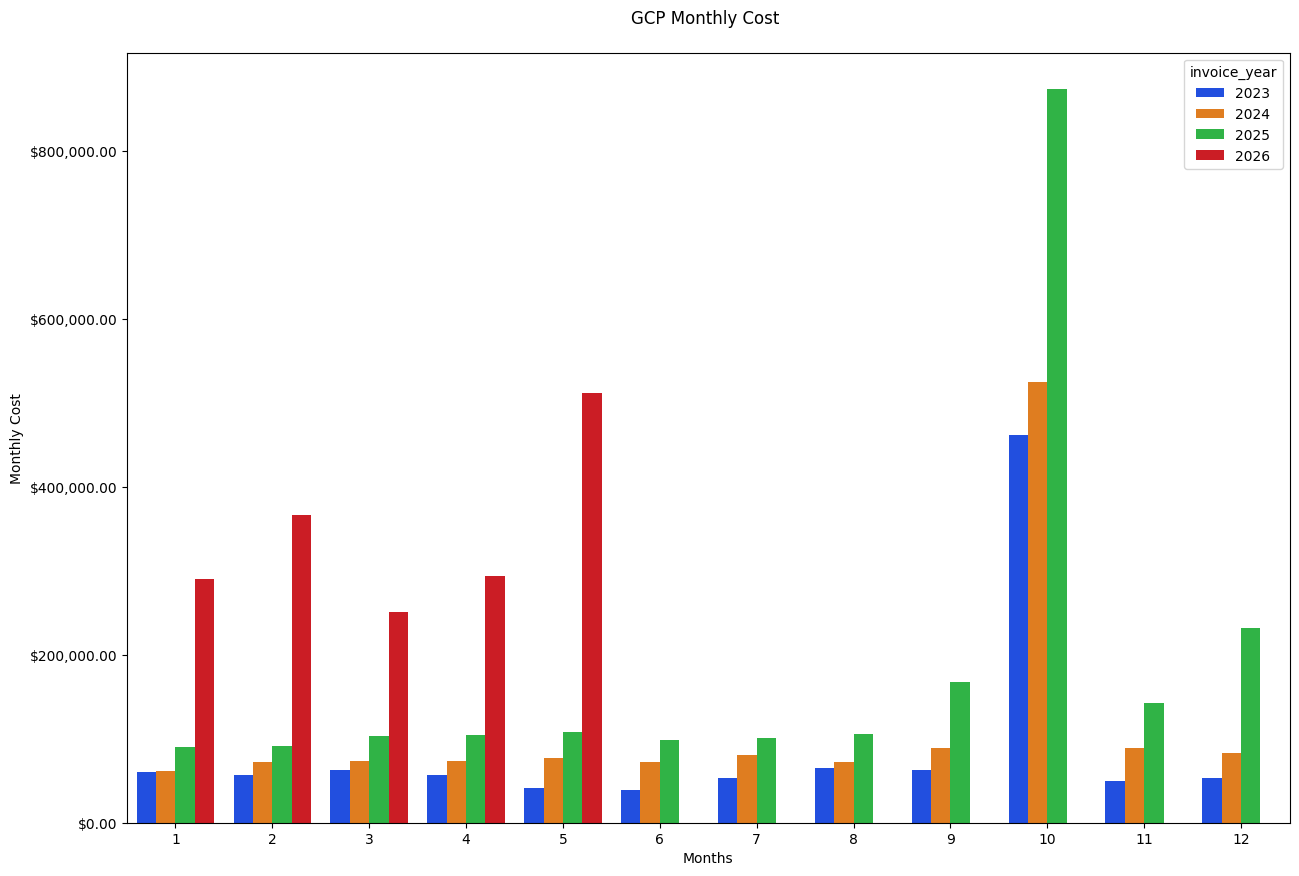

In [6]:
# Initialize the matplotlib figure
#sns.color_palette("viridis", as_cmap=True)
sns.color_palette("bright")
fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(x="invoice_month", y="Total_cost_per_Month", data=total_per_month_df,
            hue='invoice_year', legend=True, color='green',palette='bright')


# Add a legend and informative axis label
#ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set_xlabel("Months")
ax.set_ylabel("Monthly Cost")
ax.set_title("GCP Monthly Cost \n")
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.2f}".format(int(x))))
plt.savefig("AWS Monthly Cost")


#sns.despine(left=True, bottom=True)

/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_40675/1677840188.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


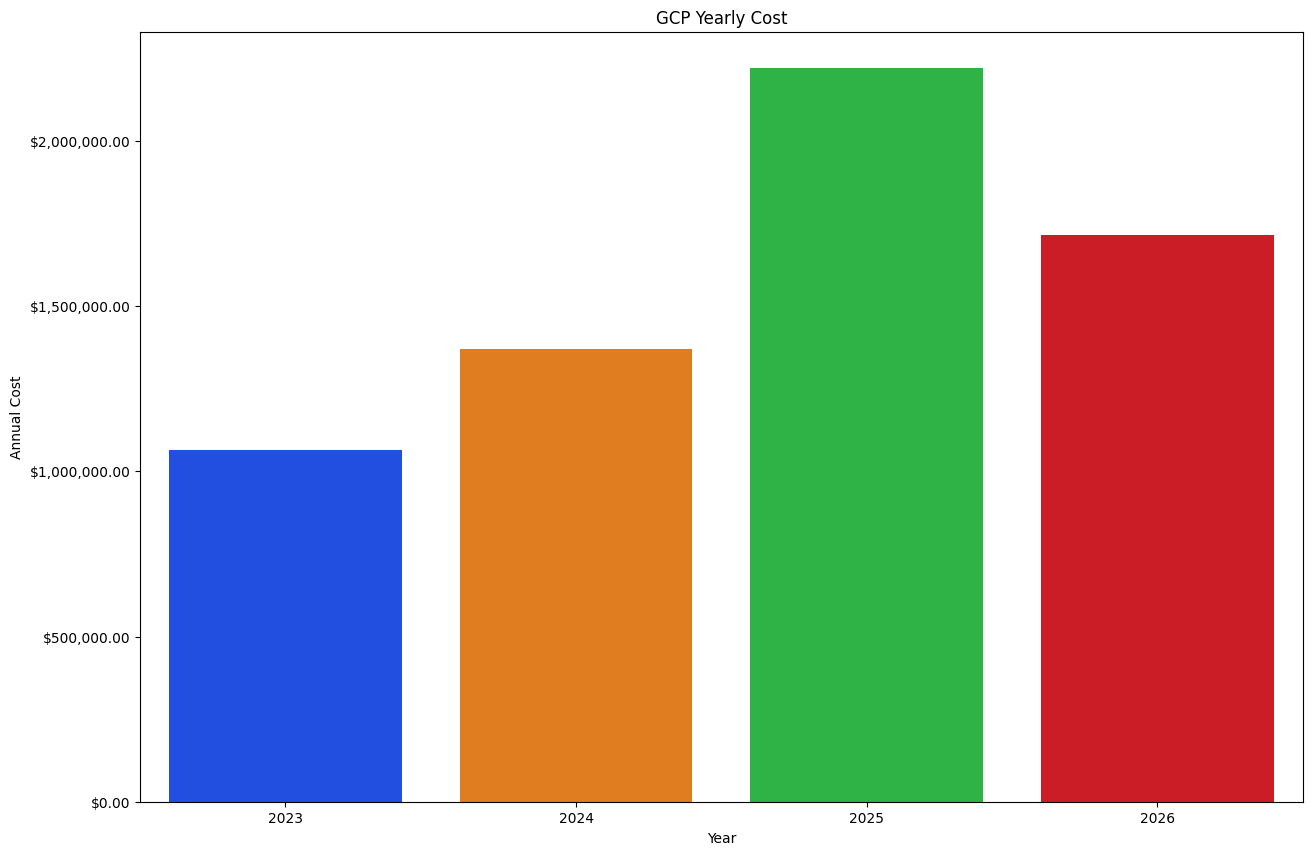

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate total cost per year
total_per_year_df = (
    total_per_month_df
    .reset_index()
    .groupby("invoice_year", as_index=False)["Total_cost_per_Month"]
    .sum()
    .rename(columns={"Total_cost_per_Month": "Total_cost_per_Year"})
)

sns.color_palette("bright")

fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(
    x="invoice_year",
    y="Total_cost_per_Year",
    data=total_per_year_df,
    palette="bright",
    ax=ax
)

# Labels and formatting
ax.set_xlabel("Year")
ax.set_ylabel("Annual Cost")
ax.set_title("GCP Yearly Cost")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f"${x:,.2f}")
)

plt.show()




In [ ]:
# df = pd.read_csv('GCP_Monthly_Cost_For_10_2024.csv') 

In [ ]:
# df['cost'].max()

In [ ]:
# df[df['cost'] == 408274.31]['service_description']

In [ ]:
# df.iloc[838044,:]

In [ ]:
#df_c = combined_df.copy()

In [8]:
total_per_project_df = combined_df.groupby(['invoice_year','project_id','project_name']).agg(Total=('cost','sum'))

In [ ]:
#total_per_project_df = df.groupby(['invoice_year','project_name']).agg(Total=('cost','sum'))

In [9]:
total_per_service_df = combined_df.groupby(['invoice_year','service_description']).agg(Total=('cost','sum'))

In [10]:
services_df = total_per_service_df[total_per_service_df['Total'] > 100]

In [11]:
projects_df = total_per_project_df[total_per_project_df['Total'] > 100]

In [12]:
projects_df

Total
invoice_year project_id              project_name                          
2023         arched-hybrid-112221    BetQL Main               136284.454650
             aud-dc-fortinet-prod    aud-dc-fortinet-prod        646.960936
             audacy-backupdr         entit-backupdr-prd-0122   87046.791746
             audacy-dc-backupdr      audacy-dc-backupdr        55350.435600
             biqquery-poc-0123       biqquery-poc-0123         21785.498137
...                                                                     ...
2026         sra-xdr-sentinel-330418 SRA-XDR-Sentinel          34609.808427
             uap-ga360-data          UAP GA360 Data             1692.374118
             wo-ondemand-qa          wo-ondemand-qa              363.217076
             wo-wos-reporting-291617 wo-wos-reporting-dev      34840.249116
             wo-wos-reporting-prod   wo-wos-reporting-prod    314973.189530

[134 rows x 1 columns]

In [13]:
services_df

Total
invoice_year service_description                    
2023         Anthos / GDC-V              2146.928323
             App Engine                 36362.840409
             BigQuery                  298211.431812
             BigQuery Reservation API  221950.034917
             BigQuery Storage API         816.060396
...                                              ...
2026         Support                   178837.490569
             VMware Engine               3968.974232
             Vertex AI                  17517.382361
             Vertex AI Search             860.186952
             Workday Inc on Google     286208.000000

[119 rows x 1 columns]

/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_40675/928247486.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


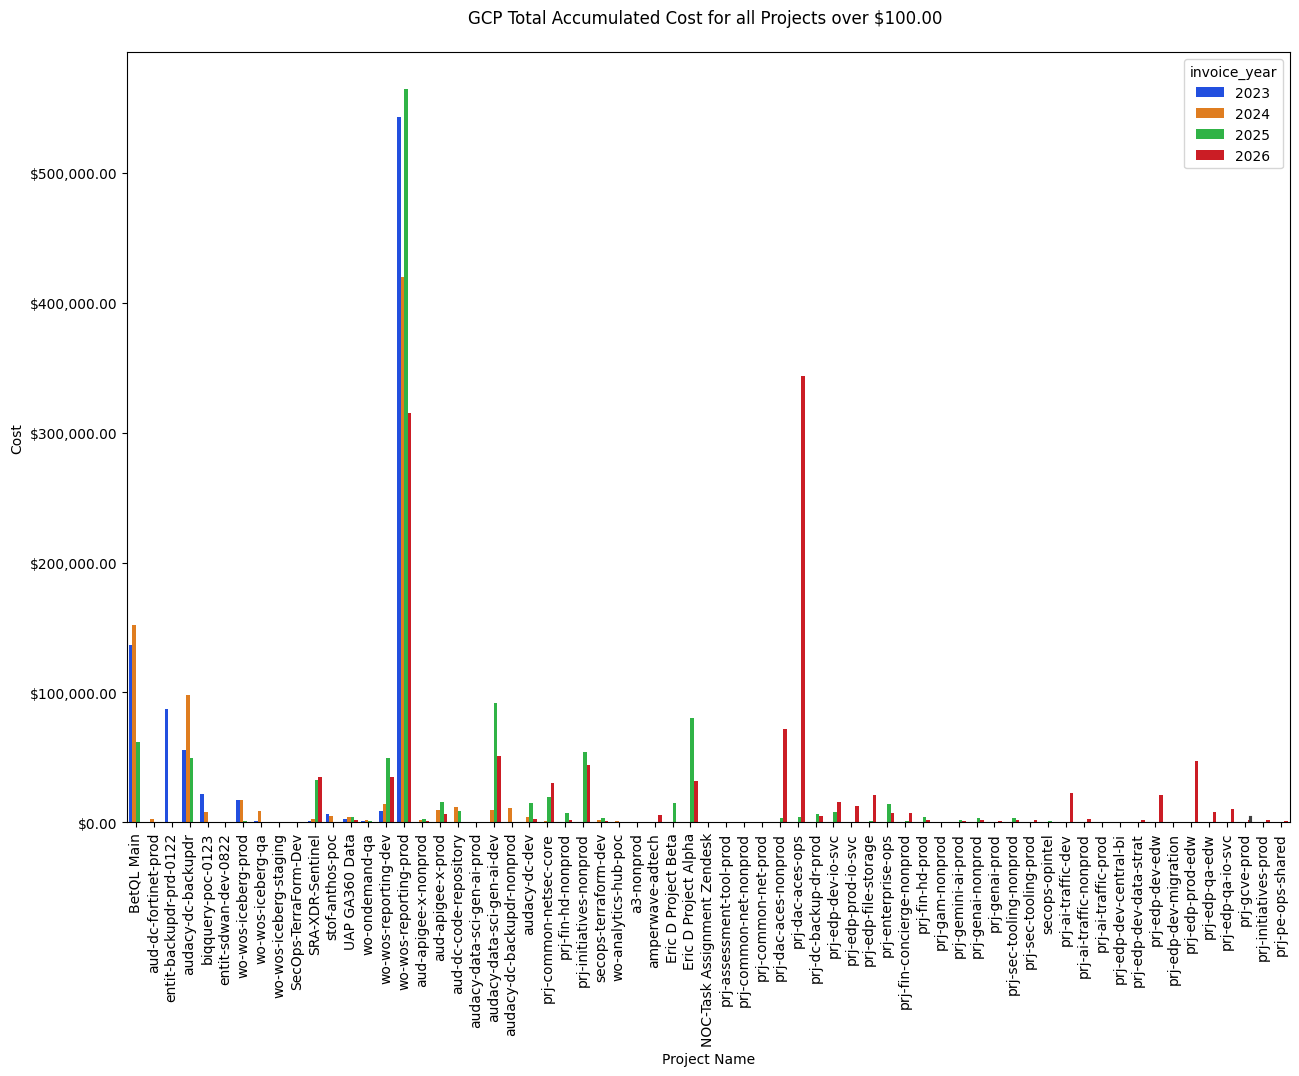

In [14]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(x="project_name", y="Total", data=projects_df,
            hue='invoice_year', legend=True, color='green',palette='bright')


# Add a legend and informative axis label
#ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set_xlabel("Project Name")
ax.set_ylabel("Cost")
ax.set_title("GCP Total Accumulated Cost for all Projects over $100.00 \n")
#ax.set_title("AWS Total Cost for Jun, 2024 by Services over $100,000 \n")
#plt.xticks(rotation=90) 
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
#ax.set_xticklabels(labels=services_df['Service'],rotation=45)
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.2f}".format(int(x))))
plt.savefig("GCP Yearly Cost by Project Name")

/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_87901/3415488098.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='project_name', x='2025_Cost', data=new_projects.head(10),
/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_87901/3415488098.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='project_name', x='Cost_Change', data=top_changes,


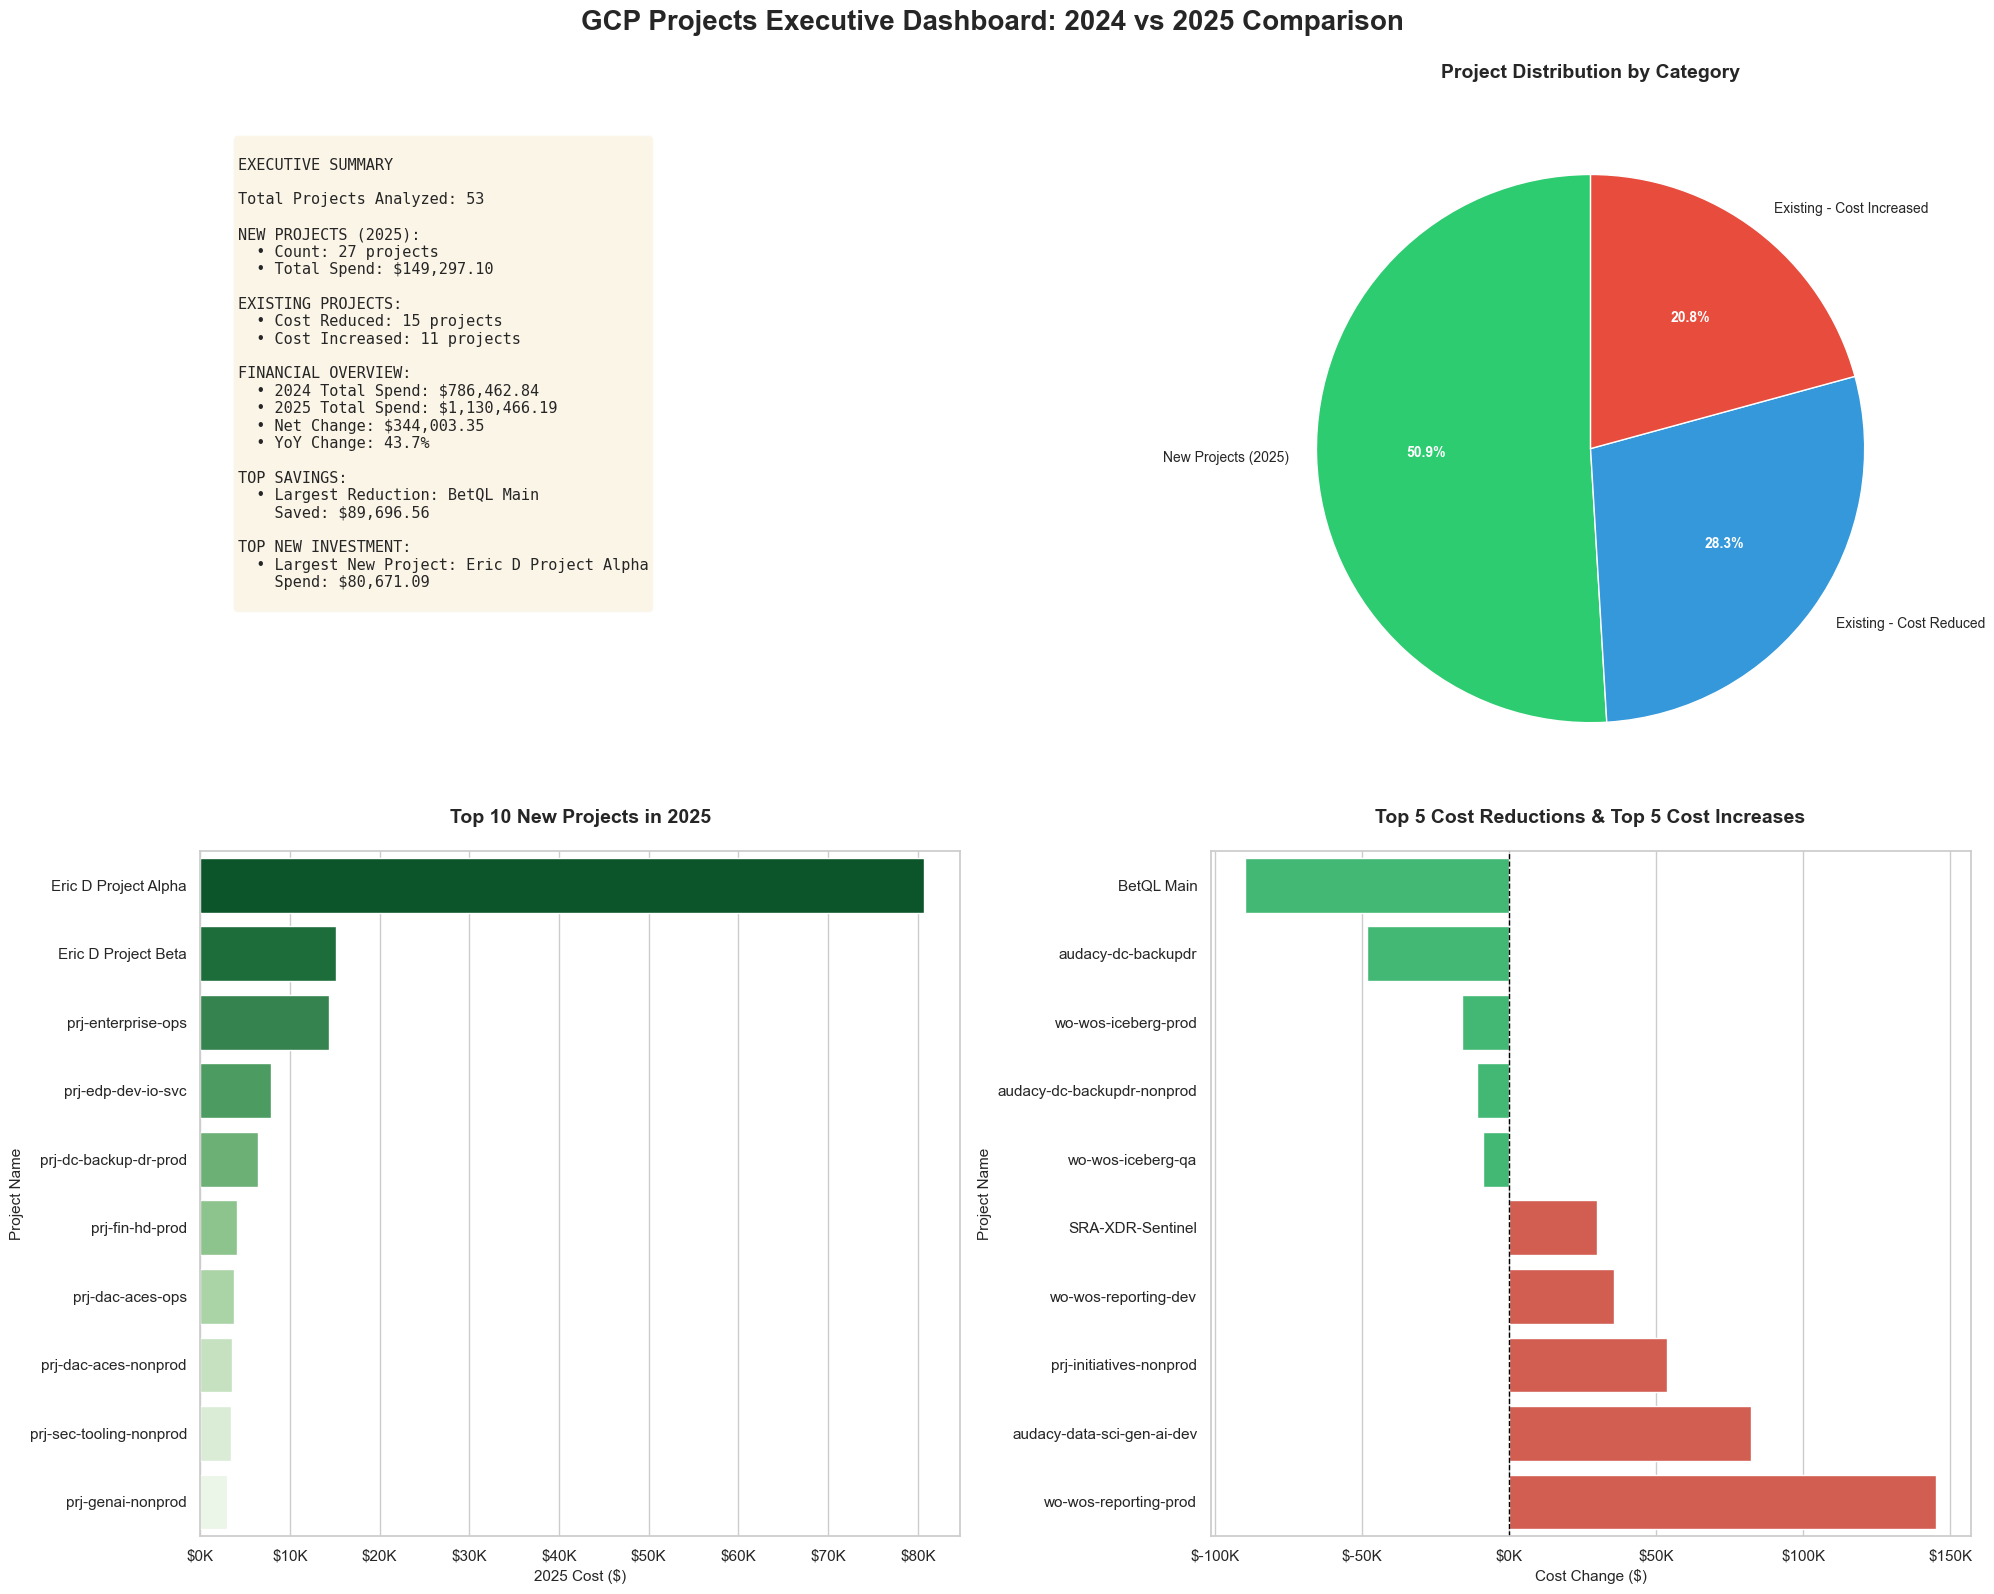


DETAILED EXECUTIVE SUMMARY: 2024 vs 2025

Total 2024 Spend: $786,462.84
Total 2025 Spend: $1,130,466.19
Net Change: $344,003.35 (43.7%)

--------------------------------------------------------------------------------

New Projects (2025): 27
Existing Projects - Cost Reduced: 15
Existing Projects - Cost Increased: 11


Detailed comparison exported to: GCP_Projects_2024_vs_2025_Comparison.csv


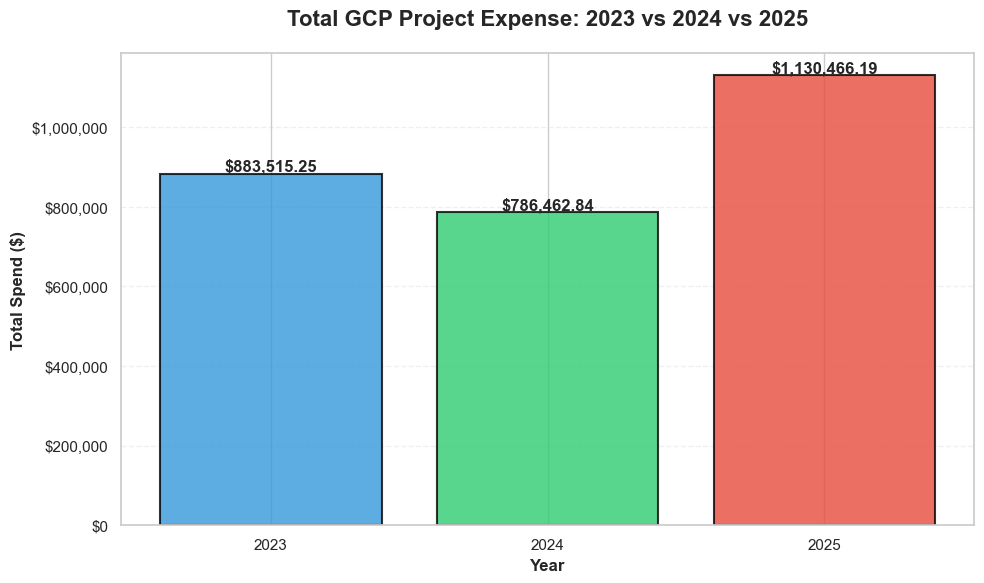

Total expense comparison chart saved to: GCP_Total_Expense_2023_vs_2024_vs_2025.png


In [57]:
# Create comprehensive executive dashboard comparing 2024 vs 2025

# Reset index to work with the data more easily
projects_comparison = projects_df.reset_index()

# Pivot to get 2024 and 2025 costs side by side
projects_pivot = projects_comparison.pivot_table(
    index=['project_id', 'project_name'], 
    columns='invoice_year', 
    values='Total', 
    fill_value=0
).reset_index()

# Calculate year-over-year changes
projects_pivot['2024_Cost'] = projects_pivot.get(2024, 0)
projects_pivot['2025_Cost'] = projects_pivot.get(2025, 0)
projects_pivot['Cost_Change'] = projects_pivot['2025_Cost'] - projects_pivot['2024_Cost']
projects_pivot['Percent_Change'] = ((projects_pivot['2025_Cost'] - projects_pivot['2024_Cost']) / 
                                     projects_pivot['2024_Cost'].replace(0, 1)) * 100

# Categorize projects
projects_pivot['Category'] = 'Existing - Cost Reduced'
projects_pivot.loc[projects_pivot['2024_Cost'] == 0, 'Category'] = 'New Projects (2025)'
projects_pivot.loc[(projects_pivot['2024_Cost'] > 0) & (projects_pivot['Cost_Change'] > 0), 'Category'] = 'Existing - Cost Increased'
projects_pivot.loc[(projects_pivot['2024_Cost'] > 0) & (projects_pivot['Cost_Change'] == 0), 'Category'] = 'Existing - No Change'

# Summary statistics
summary_stats = {
    'New Projects in 2025': len(projects_pivot[projects_pivot['Category'] == 'New Projects (2025)']),
    'Projects with Cost Reduction': len(projects_pivot[projects_pivot['Category'] == 'Existing - Cost Reduced']),
    'Projects with Cost Increase': len(projects_pivot[projects_pivot['Category'] == 'Existing - Cost Increased']),
    'Total 2023 Spend': projects_pivot.get(2023, pd.Series([0])).sum() if 2023 in projects_pivot.columns else 0,
    'Total 2024 Spend': projects_pivot['2024_Cost'].sum(),
    'Total 2025 Spend': projects_pivot['2025_Cost'].sum(),
    'Net Change': projects_pivot['Cost_Change'].sum(),
    'Percent Change': ((projects_pivot['2025_Cost'].sum() - projects_pivot['2024_Cost'].sum()) / 
                       projects_pivot['2024_Cost'].sum()) * 100
}

# Top 10 projects by category
new_projects = projects_pivot[projects_pivot['Category'] == 'New Projects (2025)'].nlargest(10, '2025_Cost')
cost_reduced = projects_pivot[projects_pivot['Category'] == 'Existing - Cost Reduced'].nsmallest(10, 'Cost_Change')
cost_increased = projects_pivot[projects_pivot['Category'] == 'Existing - Cost Increased'].nlargest(10, 'Cost_Change')

# Create executive summary visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('GCP Projects Executive Dashboard: 2024 vs 2025 Comparison', fontsize=20, fontweight='bold', y=0.995)

# 1. Summary Metrics (Top Left)
ax1 = axes[0, 0]
ax1.axis('off')
summary_text = f"""
EXECUTIVE SUMMARY

Total Projects Analyzed: {len(projects_pivot)}

NEW PROJECTS (2025):
  • Count: {summary_stats['New Projects in 2025']} projects
  • Total Spend: ${summary_stats['Total 2025 Spend'] - projects_pivot[projects_pivot['2024_Cost'] > 0]['2025_Cost'].sum():,.2f}

EXISTING PROJECTS:
  • Cost Reduced: {summary_stats['Projects with Cost Reduction']} projects
  • Cost Increased: {summary_stats['Projects with Cost Increase']} projects

FINANCIAL OVERVIEW:
  • 2024 Total Spend: ${summary_stats['Total 2024 Spend']:,.2f}
  • 2025 Total Spend: ${summary_stats['Total 2025 Spend']:,.2f}
  • Net Change: ${summary_stats['Net Change']:,.2f}
  • YoY Change: {summary_stats['Percent Change']:.1f}%

TOP SAVINGS:
  • Largest Reduction: {cost_reduced.iloc[0]['project_name']}
    Saved: ${abs(cost_reduced.iloc[0]['Cost_Change']):,.2f}

TOP NEW INVESTMENT:
  • Largest New Project: {new_projects.iloc[0]['project_name']}
    Spend: ${new_projects.iloc[0]['2025_Cost']:,.2f}
"""
ax1.text(0.05, 0.95, summary_text, transform=ax1.transAxes, fontsize=11, 
         verticalalignment='top', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# 2. Category Distribution (Top Right)
ax2 = axes[0, 1]
category_counts = projects_pivot['Category'].value_counts()
colors_pie = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
wedges, texts, autotexts = ax2.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
                                     colors=colors_pie, startangle=90, textprops={'fontsize': 10})
ax2.set_title('Project Distribution by Category', fontsize=14, fontweight='bold', pad=20)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 3. Top 10 New Projects (Bottom Left)
ax3 = axes[1, 0]
if len(new_projects) > 0:
    sns.barplot(y='project_name', x='2025_Cost', data=new_projects.head(10), 
                palette='Greens_r', ax=ax3)
    ax3.set_title('Top 10 New Projects in 2025', fontsize=14, fontweight='bold', pad=20)
    ax3.set_xlabel('2025 Cost ($)', fontsize=11)
    ax3.set_ylabel('Project Name', fontsize=11)
    ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x/1000:,.0f}K"))
else:
    ax3.text(0.5, 0.5, 'No New Projects', ha='center', va='center', fontsize=14)
    ax3.set_title('Top 10 New Projects in 2025', fontsize=14, fontweight='bold', pad=20)

# 4. Top Cost Changes (Bottom Right)
ax4 = axes[1, 1]
# Combine top increases and reductions
top_changes = pd.concat([
    cost_increased.head(5),
    cost_reduced.head(5)
]).sort_values('Cost_Change', ascending=True)

colors_bar = ['#2ecc71' if x < 0 else '#e74c3c' for x in top_changes['Cost_Change']]
sns.barplot(y='project_name', x='Cost_Change', data=top_changes, 
            palette=colors_bar, ax=ax4)
ax4.set_title('Top 5 Cost Reductions & Top 5 Cost Increases', fontsize=14, fontweight='bold', pad=20)
ax4.set_xlabel('Cost Change ($)', fontsize=11)
ax4.set_ylabel('Project Name', fontsize=11)
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x/1000:,.0f}K"))
ax4.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig("GCP_Executive_Dashboard_2024_vs_2025.png", dpi=300, bbox_inches='tight')
plt.show()

# Print detailed summary
print("\n" + "="*80)
print("DETAILED EXECUTIVE SUMMARY: 2024 vs 2025")
print("="*80)
print(f"\nTotal 2024 Spend: ${summary_stats['Total 2024 Spend']:,.2f}")
print(f"Total 2025 Spend: ${summary_stats['Total 2025 Spend']:,.2f}")
print(f"Net Change: ${summary_stats['Net Change']:,.2f} ({summary_stats['Percent Change']:.1f}%)")
print("\n" + "-"*80)
print(f"\nNew Projects (2025): {summary_stats['New Projects in 2025']}")
print(f"Existing Projects - Cost Reduced: {summary_stats['Projects with Cost Reduction']}")
print(f"Existing Projects - Cost Increased: {summary_stats['Projects with Cost Increase']}")
print("\n" + "="*80)

# Export detailed comparison to CSV
projects_pivot_export = projects_pivot[['project_id', 'project_name', 'Category', 
                                        '2024_Cost', '2025_Cost', 'Cost_Change', 'Percent_Change']]
projects_pivot_export = projects_pivot_export.sort_values('Cost_Change', ascending=True)
projects_pivot_export.to_csv("GCP_Projects_2024_vs_2025_Comparison.csv", index=False)
print("\nDetailed comparison exported to: GCP_Projects_2024_vs_2025_Comparison.csv")

# Create additional visualization for total expense comparison
fig_expense, ax_expense = plt.subplots(1, 1, figsize=(10, 6))

# Data for the bar chart
years = ['2023', '2024', '2025']
expenses = [summary_stats['Total 2023 Spend'], summary_stats['Total 2024 Spend'], summary_stats['Total 2025 Spend']]
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Create bar chart
bars = ax_expense.bar(years, expenses, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for bar, expense in zip(bars, expenses):
  height = bar.get_height()
  ax_expense.text(bar.get_x() + bar.get_width()/2., height,
           f'${expense:,.2f}',
           ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add percentage change annotation
#change_pct = summary_stats['Percent Change']
#change_amt = summary_stats['Net Change']
#ax_expense.text(0.5, max(expenses) * 0.5, 
#         f'YoY Change: +${change_amt:,.2f}\n({change_pct:.1f}%)',
#         ha='center', va='center', fontsize=14, fontweight='bold',
#         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# Formatting
ax_expense.set_ylabel('Total Spend ($)', fontsize=12, fontweight='bold')
ax_expense.set_xlabel('Year', fontsize=12, fontweight='bold')
ax_expense.set_title('Total GCP Project Expense: 2023 vs 2024 vs 2025', fontsize=16, fontweight='bold', pad=20)
ax_expense.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax_expense.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig("GCP_Total_Expense_2023_vs_2024_vs_2025.png", dpi=300, bbox_inches='tight')
plt.show()

print("Total expense comparison chart saved to: GCP_Total_Expense_2023_vs_2024_vs_2025.png")

/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_40675/2937903153.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


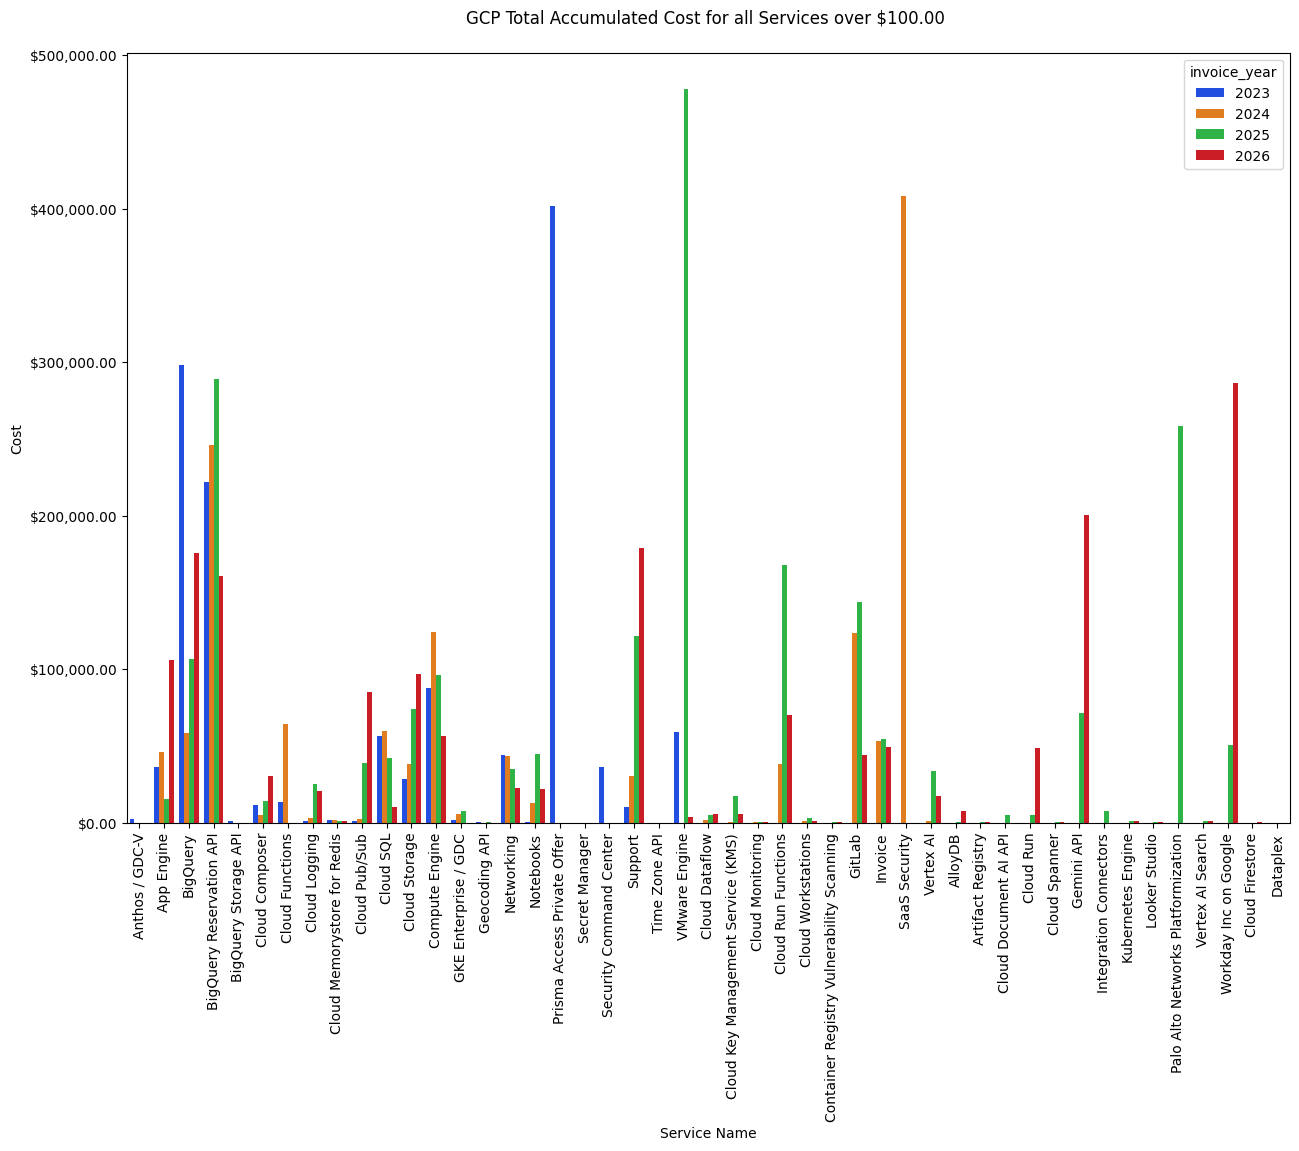

: 

In [ ]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(x="service_description", y="Total", data=services_df,
            hue='invoice_year', legend=True, color='green',palette='bright')


# Add a legend and informative axis label
#ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set_xlabel("Service Name")
ax.set_ylabel("Cost")
ax.set_title("GCP Total Accumulated Cost for all Services over $100.00 \n")
#ax.set_title("AWS Total Cost for Jun, 2024 by Services over $100,000 \n")
#plt.xticks(rotation=90) 
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
#ax.set_xticklabels(labels=services_df['Service'],rotation=45)
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.2f}".format(int(x))))
plt.savefig("GCP Yearly Cost by Service ID")

In [59]:

#df[df[['project_name'] == 'wo-wos-reporting-prod'  ['invoice_year'] == 2025]]

w = combined_df.query('project_name == "wo-wos-reporting-prod" and invoice_year <= 2025')
w['service_description'].unique()



array(['Cloud Pub/Sub', 'Cloud Logging', 'Compute Engine',
       'Cloud Storage', 'Deep Learning VM', 'Cloud Run Functions',
       'Notebooks', 'Cloud SQL', 'Vertex AI', 'BigQuery', 'Support',
       'Artifact Registry', 'BigQuery Storage API',
       'BigQuery Reservation API', 'Networking', 'Cloud Scheduler',
       'Cloud Build', 'Invoice', 'Secret Manager', 'Cloud Functions',
       'Cloud Composer', 'Stackdriver Monitoring', 'Cloud Monitoring',
       'Dataplex'], dtype=object)

In [60]:
w = combined_df.query('project_name == "audacy-dc-backupdr" and invoice_year <= 2026')
w['service_description'].unique()

array(['Networking', 'Compute Engine', 'Cloud Logging', 'Support',
       'Cloud DNS', 'Cloud Storage', 'Invoice', 'Ceph Cluster',
       'Cloud Run'], dtype=object)

In [16]:
w = combined_df.query('project_name == "Eric D Project Alpha" and invoice_year <= 2025')
w['service_description'].unique()

array(['Invoice', 'Cloud Run', 'Vertex AI', 'Cloud Spanner',
       'Compute Engine', 'Dataplex', 'BigQuery', 'Cloud Storage',
       'Cloud Logging', 'Data Catalog', 'Secret Manager',
       'Artifact Registry', 'Cloud Build', 'Gemini API',
       'Vertex AI Search', 'Geocoding API', 'App Engine', 'Cloud Pub/Sub',
       'Networking', 'Cloud Tasks',
       'Google Maps Platform Weather Service', 'Places API',
       'Firebase App Hosting', 'Firebase Hosting', 'Cloud Monitoring',
       'Deep Learning VM', 'Cloud Scheduler',
       'Container Registry Vulnerability Scanning', 'Identity Platform',
       'Cloud Run Functions', 'Cloud Dataflow',
       'Cloud Text-to-Speech API'], dtype=object)

In [61]:
total_per_service_df = w.groupby(['invoice_year','service_description']).agg(Total=('cost','sum'))

In [62]:
services_df = total_per_service_df[total_per_service_df['Total'] > 100]

In [63]:
total_per_service_df

Total
invoice_year service_description              
2023         Cloud DNS                0.000768
             Cloud Logging          511.997624
             Cloud Run                0.000028
             Cloud Storage         1313.627983
             Compute Engine       18526.287419
             Invoice                342.403110
             Networking           33876.948734
             Support                779.169934
2024         Ceph Cluster             0.000000
             Cloud DNS                7.621697
             Cloud Logging           42.810338
             Cloud Storage        16389.126077
             Compute Engine       41100.210780
             Invoice                459.030471
             Networking           37472.311380
             Support               2692.364565
2025         Cloud DNS                5.320719
             Cloud Logging          117.108713
             Cloud Storage         1151.985132
             Compute Engine       23848.442274
             Invoice                219.956474
             Networking           24397.645484

/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_87901/2595854041.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


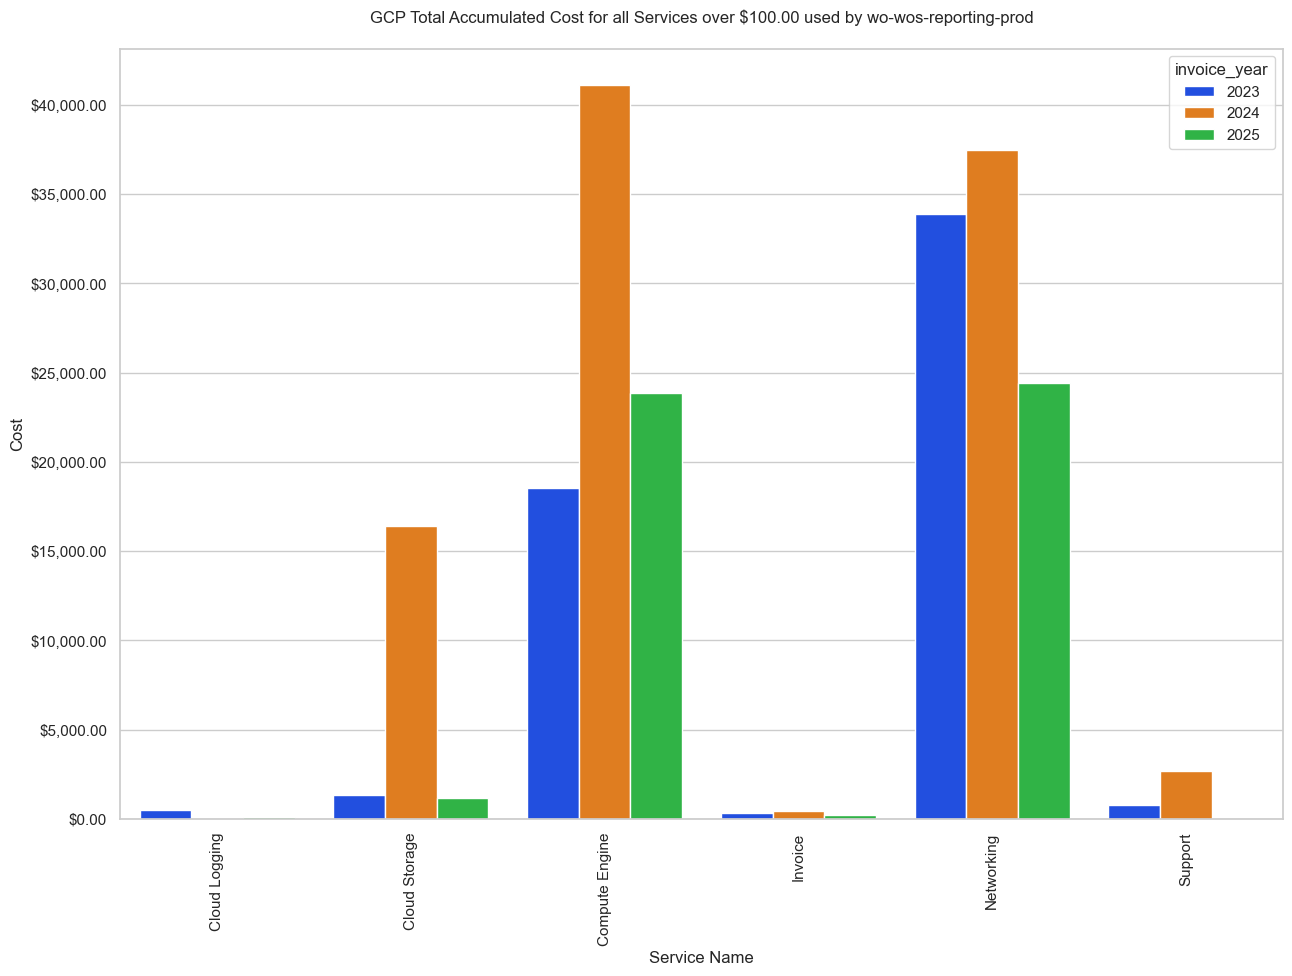

: 

In [ ]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(x="service_description", y="Total", data=services_df,
            hue='invoice_year', legend=True, color='green',palette='bright')


# Add a legend and informative axis label
#ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set_xlabel("Service Name")
ax.set_ylabel("Cost")
ax.set_title("GCP Total Accumulated Cost for all Services over $100.00 used by wo-wos-reporting-prod\n")
#ax.set_title("AWS Total Cost for Jun, 2024 by Services over $100,000 \n")
#plt.xticks(rotation=90) 
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
#ax.set_xticklabels(labels=services_df['Service'],rotation=45)
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.2f}".format(int(x))))
plt.savefig("GCP Yearly Cost by Service ID")

# This section is a manual way to get rows without SQL < BEGIN >

In [30]:

tbl = client.get_table(table_id)
schema = tbl.schema

In [31]:
len(schema)

22

In [32]:
column_names = []
for i in range(0,22):
    print("-"*30)
    print (tbl.schema[i].name)
    print (tbl.schema[i].field_type)
    print (tbl.schema[i].mode)
    print (tbl.schema[i].description)
    column_names.append(tbl.schema[i].name)

------------------------------
billing_account_id
STRING
NULLABLE

------------------------------
service
RECORD
NULLABLE

------------------------------
sku
RECORD
NULLABLE

------------------------------
usage_start_time
TIMESTAMP
NULLABLE

------------------------------
usage_end_time
TIMESTAMP
NULLABLE

------------------------------
project
RECORD
NULLABLE

------------------------------
labels
RECORD
REPEATED

------------------------------
system_labels
RECORD
REPEATED

------------------------------
location
RECORD
NULLABLE

------------------------------
tags
RECORD
REPEATED

------------------------------
export_time
TIMESTAMP
NULLABLE

------------------------------
cost
FLOAT
NULLABLE

------------------------------
currency
STRING
NULLABLE

------------------------------
currency_conversion_rate
FLOAT
NULLABLE

------------------------------
usage
RECORD
NULLABLE

------------------------------
credits
RECORD
REPEATED

------------------------------
invoice
RECORD
NULLABLE

In [33]:
column_names

['billing_account_id',
 'service',
 'sku',
 'usage_start_time',
 'usage_end_time',
 'project',
 'labels',
 'system_labels',
 'location',
 'tags',
 'export_time',
 'cost',
 'currency',
 'currency_conversion_rate',
 'usage',
 'credits',
 'invoice',
 'cost_type',
 'adjustment_info',
 'cost_at_list',
 'transaction_type',
 'seller_name']

In [34]:
schema_df = pd.DataFrame(columns=column_names)

print(schema_df)

Empty DataFrame
Columns: [billing_account_id, service, sku, usage_start_time, usage_end_time, project, labels, system_labels, location, tags, export_time, cost, currency, currency_conversion_rate, usage, credits, invoice, cost_type, adjustment_info, cost_at_list, transaction_type, seller_name]
Index: []

[0 rows x 22 columns]


In [35]:
schema_df.columns 

Index(['billing_account_id', 'service', 'sku', 'usage_start_time',
       'usage_end_time', 'project', 'labels', 'system_labels', 'location',
       'tags', 'export_time', 'cost', 'currency', 'currency_conversion_rate',
       'usage', 'credits', 'invoice', 'cost_type', 'adjustment_info',
       'cost_at_list', 'transaction_type', 'seller_name'],
      dtype='object')

In [36]:
schema_df

,billing_account_id,service,sku,usage_start_time,usage_end_time,project,labels,system_labels,location,tags,...,currency,currency_conversion_rate,usage,credits,invoice,cost_type,adjustment_info,cost_at_list,transaction_type,seller_name


In [38]:
rows = client.list_rows(table_id)

In [41]:

j = 0
save_record = 0
for row in rows:
    data = []
    #print(row)
    print(j)
    j += 1
    save_record += 1
    for i in range(0,22):
        #print(column_names[i],':')
        #print(row[i])
        data.append(row[i])
        #if i in [1,2] :
        #    print(rows[0][i]['id'], " - ", rows[0][i]['description'])
    row_data = dict(zip(column_names,data))
    schema_df = schema_df.append(row_data, ignore_index=True)
    if save_record == 5000 :
        save_record = 0
        schema_df.to_csv("GCP.csv")
        print("CSV File Saved.....")
    
    

'\nj = 0\nsave_record = 0\nfor row in rows:\n    data = []\n    #print(row)\n    print(j)\n    j += 1\n    save_record += 1\n    for i in range(0,22):\n        #print(column_names[i],\':\')\n        #print(row[i])\n        data.append(row[i])\n        #if i in [1,2] :\n        #    print(rows[0][i][\'id\'], " - ", rows[0][i][\'description\'])\n    row_data = dict(zip(column_names,data))\n    schema_df = schema_df.append(row_data, ignore_index=True)\n    if save_record == 5000 :\n        save_record = 0\n        schema_df.to_csv("GCP.csv")\n        print("CSV File Saved.....")\n    \n    \n'

In [43]:
table

In [45]:

iterator = client.list_rows(table)
page = next(iterator.pages)
rows = list(page)
total = iterator.total_rows
token = iterator.next_page_token



'\niterator = client.list_rows(table)\npage = next(iterator.pages)\nrows = list(page)\ntotal = iterator.total_rows\ntoken = iterator.next_page_token\n'

# This section is a manual way to get rows without SQL < END >